# Capstone Project: Data Analysis
## Study Case: Fraud Mitigation

##### Notice:
The dataset used in this analysis is a dummy dataset. It doesn't contain actual, sensitive, and real business data.

#### Goals:
To understand our data, and identify specific patterns that may lead to suspicious transactions (which have financial impact on business)\
Improving database quality

#### Business Questions:
This analysis is to answer these business questions:
1. Is there any user that violate Indonesian Central Bank regulations; wallet balance and transaction limit per month?
2. Is there any user that breached security measure; unauthorized P2P transfer by users who haven't done KYC process?
3. Is there any inconsistencies in our dataset?
4. Is there any outliers amount, and/or surpassed threshold as regulated?

#### Stakeholders:
1. Security Engineer; to enhance security in current system 
2. Database Administrator; to ensure Database is in good quality
3. Legal Department; who need to extract database and report to Indonesian Central Bank (BI) and Financial Services Authority (OJK)

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

#For Display
from IPython.display import display_html
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format = '{:.2f}'.format

In [2]:
path = 'C:\\Data Files\\Study\\Purwadhika\\Capstone Projects\\Capstone Modul 2\\OVO\\'

### Import Dataset

In [3]:
#Import Data, show 5 first rows 
df_users = pd.read_csv(path + 'ovo_users.csv')
df_merchants = pd.read_csv(path + 'ovo_merchants.csv')
df_trans = pd.read_csv(path + 'ovo_transactions.csv')

### About Dataset

**Table User:**\
user_id : Unique user account ID\
join_date : User account creation/joining date\
kyc_status : OVO Club (Unregistered; Not Verified with Official ID) & OVO Premier (Registered; Verified with Official ID)\
kyc_date : Verification Date (Null if not verified)\
wallet_balance: Balance as of 21 Aug 2024 (maximum balance per user is regulated by Indonesian Central Bank, for unregistered and registered user)

**Table Merchant:**\
merchant_id : Unique merchant account ID\
merchant_name : Merchant name \
category : Merchant business category | Retail, Digital, F&B, Transport, None

**Table Transactions:**\
trx_id : Unique transaction number ID\
user_id : User ID (Foreign Key)\
merchant_id : Merchant ID (Foreign Key) | None (if P2P and transaction done through internal application)\
trx_date : Transaction date\
trx_type : Transaction type | Bill Payment, QRIS, VA Bill, Top Up, P2P (P2P can’t be used by OVO Club; unverified user)\
amount : Transaction amount


### Exploratory Data Analysis

In [4]:
display(df_users.head(), df_merchants.head(), df_trans.head())

,user_id,join_date,kyc_status,kyc_date,wallet_balance
0,OVO-000001,5/10/2023,OVO Club,NaN,114132
1,OVO-000002,2/5/2023,OVO Club,NaN,4797802
2,OVO-000003,7/5/2023,OVO Premier,7/26/2023,3388067
3,OVO-000004,6/18/2023,OVO Premier,7/17/2023,949007
4,OVO-000005,7/21/2023,OVO Premier,7/24/2023,4880835


,merchant_id,merchant_name,category
0,MCH-0001,Toko Lancar 0,F&B
1,MCH-0002,Toko Jaya 1,F&B
2,MCH-0003,Toko Lancar 2,F&B
3,MCH-0004,Toko Maju 3,F&B
4,MCH-0005,Toko Berkah 4,F&B


,trx_id,user_id,merchant_id,trx_date,trx_type,amount
0,TRX-0000001,OVO-029791,MCH-1526,2024-01-30,Bill Payment,889463
1,TRX-0000002,OVO-002394,MCH-4933,2023-10-04,qris_payment,467638
2,TRX-0000003,OVO-038798,NaN,2024-05-05,Top Up,184085
3,TRX-0000004,OVO-010582,MCH-0791,2023-02-05,qris_payment,-50000
4,TRX-0000005,OVO-012520,NaN,2023-09-27,Transfer P2P,218415


In [5]:
print('Table user: ', df_users.shape)
print('Table merchant: ', df_merchants.shape)
print('Table transaction: ', df_trans.shape)

Table user:  (40000, 5)
Table merchant:  (5000, 3)
Table transaction:  (300000, 6)


In [6]:
#Merge table for analysis
df = df_trans.merge(df_users, how='left')
df = df.merge(df_merchants, how='left')
df.columns

Index(['trx_id', 'user_id', 'merchant_id', 'trx_date', 'trx_type', 'amount',
       'join_date', 'kyc_status', 'kyc_date', 'wallet_balance',
       'merchant_name', 'category'],
      dtype='str')

In [7]:
#Take necessary columns, and check data types
df = df[['trx_id', 'user_id','join_date', 'kyc_status', 'kyc_date', 'merchant_id', 'category', 'trx_date', 'trx_type', 'amount']]
df = df.sort_values(by='trx_id')
df.rename(columns={'category':'merchant_cat'},inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   trx_id        300000 non-null  str  
 1   user_id       300000 non-null  str  
 2   join_date     300000 non-null  str  
 3   kyc_status    300000 non-null  str  
 4   kyc_date      180131 non-null  str  
 5   merchant_id   144095 non-null  str  
 6   merchant_cat  136555 non-null  str  
 7   trx_date      300000 non-null  str  
 8   trx_type      300000 non-null  str  
 9   amount        300000 non-null  int64
dtypes: int64(1), str(9)
memory usage: 43.2 MB


#### Data Types
Several variables have incorrect data type, which has to be changed before analysis

In [8]:
#Change Data Type to Datetime ('trx_date', 'join_date', 'kyc_date')
df['join_date'] = pd.to_datetime(df['join_date'])
df['kyc_date'] = pd.to_datetime(df['kyc_date'])
df['trx_date'] = pd.to_datetime(df['trx_date'])


### Descriptive: Categorical Variable

In [9]:
#Understand variables from datasets

Unique_Dict = {
    'columns' : [],
    'unique_count' : [],
    'unique' : [],
    'dtype' : []
}

for idx in range( len(df.columns) ) :
    if (df[ df.columns[idx] ].dtype != 'int') & (df[ df.columns[idx] ].dtype != 'float'):
        Unique_Dict['columns'].append(df.columns[idx])
        Unique_Dict['unique_count'].append(df[df.columns[idx]].nunique())
        if (df[df.columns[idx]].nunique()) < 10:
            Unique_Dict['unique'].append(df[df.columns[idx]].unique())
        else:
            Unique_Dict['unique'].append('More than 10')
        Unique_Dict['dtype'].append(df.dtypes.iloc[idx])

pd.DataFrame(Unique_Dict)

,columns,unique_count,unique,dtype
0,trx_id,300000,More than 10,str
1,user_id,39969,More than 10,str
2,join_date,500,More than 10,datetime64[us]
3,kyc_status,2,"[OVO Club, OVO Premier]",str
4,kyc_date,527,More than 10,datetime64[us]
5,merchant_id,5000,More than 10,str
6,merchant_cat,4,"[Retail, Digital Goods, nan, F&B, Transportation]",str
7,trx_date,608,More than 10,datetime64[us]
8,trx_type,8,"[Bill Payment, qris_payment, Top Up, Transfer P2P, VA Billing, TOPUP, p2p_tf, QRIS]",str


In [10]:
df.describe(include='all')

,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount
count,300000,300000,300000,300000,180131,144095,136555,300000,300000,300000.00
unique,300000,39969,NaN,2,NaN,5000,4,NaN,8,NaN
top,TRX-0000001,OVO-032172,NaN,OVO Premier,NaN,MCH-0630,F&B,NaN,Transfer P2P,NaN
freq,1,21,NaN,180131,NaN,57,57776,NaN,47923,NaN
mean,NaN,NaN,2023-09-07 21:24:11.807999,NaN,2023-09-21 18:41:13.439885,NaN,NaN,2023-10-26 20:58:12.864000,NaN,6898260.48
min,NaN,NaN,2023-01-01 00:00:00,NaN,2023-01-02 00:00:00,NaN,NaN,2022-12-20 00:00:00,NaN,-50000.00
25%,NaN,NaN,2023-05-06 00:00:00,NaN,2023-05-19 00:00:00,NaN,NaN,2023-06-24 00:00:00,NaN,255033.75
50%,NaN,NaN,2023-09-08 00:00:00,NaN,2023-09-22 00:00:00,NaN,NaN,2023-10-28 00:00:00,NaN,505276.00
75%,NaN,NaN,2024-01-11 00:00:00,NaN,2024-01-25 00:00:00,NaN,NaN,2024-02-29 00:00:00,NaN,757599.00
max,NaN,NaN,2024-05-14 00:00:00,NaN,2024-06-11 00:00:00,NaN,NaN,2024-08-21 00:00:00,NaN,850000000.00


#### Categorical Variable across dataset
1. KYC has 2 category: OVO Club & OVO Premier, no NaN values
2. Merchant has 4 category, with 1 NaN value
4. Transaction type: Bill Payment, QRIS, Top Up, Transfer P2P, VA Bill (Need to be cleaned)

#### Syarat & Ketentuan OVO:
Source: https://www.ovo.id/syarat-ketentuan

Kami menawarkan 2 (dua) jenis klasifikasi akun keanggotaan Pengguna OVO, sebagai berikut:\
**OVO Club (Unregistered E-Money)**\
OVO Club adalah klasifikasi akun Pengguna OVO yang merupakan pengguna uang elektronik unregistered sebagaimana diatur dalam Peraturan Bank Indonesia yang mengatur mengenai penyelenggaraan uang elektronik.\
Jika Anda berhasil melakukan pendaftaran dengan menggunakan nomor ponsel dan alamat email maka Anda akan langsung menjadi Pengguna OVO dengan klasifikasi akun OVO Club.\
Pengguna OVO dengan klasifikasi OVO Club dapat menggunakan beberapa layanan uang elektronik secara terbatas, yaitu:
akun Anda dapat **menampung saldo OVO Cash dengan batas maksimum Rp2.000.000,- (dua juta Rupiah)**, batas maksimum tersebut dapat berubah sewaktu-waktu dan secara otomatis mengikuti perubahan dan/atau pemberlakuan ketentuan Bank Indonesia;\
akun Anda dapat menerima pengisian saldo OVO Cash (top up) dengan mengacu pada batasan yang dimaksud dalam poin (a) di atas; dan
layanan pemrosesan transaksi pembayaran untuk pembelian barang dan/atau jasa atau untuk pembayaran tagihan.\
**OVO Premier (Registered E-Money)**\
OVO Premier adalah klasifikasi akun Pengguna OVO yang merupakan pengguna uang elektronik registered sebagaimana diatur dalam Peraturan Bank Indonesia yang mengatur mengenai penyelenggaraan uang elektronik.\
Anda dapat melakukan upgrade klasifikasi akun Anda menjadi OVO Premier dengan menyerahkan data dan informasi sebagaimana Kami syaratkan dalam Sub-BAB mengenai Upgrade pada BAB ini.\
Pengguna OVO dengan klasifikasi OVO Premier dapat menggunakan seluruh layanan uang elektronik, yaitu:\
akun Anda dapat **menampung saldo OVO Cash dengan batas maksimum Rp20.000.000,- (dua puluh juta Rupiah)**, batas maksimum tersebut dapat berubah sewaktu-waktu dan secara otomatis mengikuti perubahan dan/atau pemberlakuan ketentuan Bank Indonesia; ...


#### Cleaning Process: Categorical Variable

In [11]:
#Clean categorical variable from inconsistency
df['trx_type'] = df['trx_type'].replace({'qris_payment':'QRIS', 'p2p_tf':'Transfer P2P', 'TOPUP':'Top Up'})

In [12]:
#Recheck categorical variable unique values
print ('User KYC: ', df['kyc_status'].unique() ,'\n')
print ('Merchant category: ', df['merchant_cat'].unique() ,'\n')
print ('Transaction Type: ', df['trx_type'].unique() ,'\n')

User KYC:  <ArrowStringArray>
['OVO Club', 'OVO Premier']
Length: 2, dtype: str 

Merchant category:  <ArrowStringArray>
['Retail', 'Digital Goods', nan, 'F&B', 'Transportation']
Length: 5, dtype: str 

Transaction Type:  <ArrowStringArray>
['Bill Payment', 'QRIS', 'Top Up', 'Transfer P2P', 'VA Billing']
Length: 5, dtype: str 



In [13]:
count_trx_cat = df.groupby(['trx_type','merchant_cat'],as_index=False)[['trx_id']].count().style.set_table_attributes("style='display:inline; margin-right:40px;'")
count_trx_nan = df[df['merchant_cat'].isna()==True].groupby(['trx_type'],as_index=False)[['trx_id']].count().style.set_table_attributes("style='display:inline;'")

display_html(count_trx_cat._repr_html_() + count_trx_nan._repr_html_(), raw=True)

,trx_type,merchant_cat,trx_id
0,Bill Payment,Digital Goods,5605
1,Bill Payment,F&B,14316
2,Bill Payment,Retail,10964
3,Bill Payment,Transportation,3394
4,QRIS,Digital Goods,10746
5,QRIS,F&B,28921
6,QRIS,Retail,21544
7,QRIS,Transportation,6884
8,VA Billing,Digital Goods,5336
9,VA Billing,F&B,14539


Based on dataset, Transaction Type: *Top Up* and *Transfer P2P* always don't have Merchant ID & Category.

In [14]:
#Replace merchant ID & Category for P2P and Top Up
df['merchant_id'] = np.where( (df['trx_type']=='Top Up') & (df['merchant_id'].isna()), 'TOP UP', df['merchant_id'] )
df['merchant_cat'] = np.where( (df['trx_type']=='Top Up') & (df['merchant_cat'].isna()), 'TOP UP', df['merchant_cat'] )

df['merchant_id'] = np.where( (df['trx_type']=='Transfer P2P') & (df['merchant_id'].isna()), 'P2P', df['merchant_id'] )
df['merchant_cat'] = np.where( (df['trx_type']=='Transfer P2P') & (df['merchant_cat'].isna()), 'P2P', df['merchant_cat'] )

In [15]:
total_trx = df['trx_id'].count()

count_trx_cat = df.groupby(['trx_type','merchant_cat'],as_index=False)[['trx_id']].count()
count_trx_cat['Percentage'] = count_trx_cat['trx_id'] / total_trx * 100

count_trx_nan = df[df['merchant_cat'].isna()==True].groupby(['trx_type'],as_index=False)[['trx_id']].count()
count_trx_nan['Percentage'] = count_trx_nan['trx_id'] / total_trx * 100

print("Total Percentage: ", count_trx_cat['Percentage'].sum() + count_trx_nan['Percentage'].sum() , '\n')

count_trx_cat = count_trx_cat.style.set_table_attributes("style='display:inline; margin-right:40px;'").set_caption('Cleaned Category')
count_trx_nan = count_trx_nan.style.set_table_attributes("style='display:inline;'").set_caption('Other Category')

display_html(count_trx_cat._repr_html_() + count_trx_nan._repr_html_(), raw=True)

Total Percentage:  99.99999999999999 



,trx_type,merchant_cat,trx_id,Percentage
0,Bill Payment,Digital Goods,5605,1.868333
1,Bill Payment,F&B,14316,4.772000
2,Bill Payment,Retail,10964,3.654667
3,Bill Payment,Transportation,3394,1.131333
4,QRIS,Digital Goods,10746,3.582000
5,QRIS,F&B,28921,9.640333
6,QRIS,Retail,21544,7.181333
7,QRIS,Transportation,6884,2.294667
8,Top Up,TOP UP,72044,24.014667
9,Transfer P2P,P2P,83861,27.953667


In [16]:
df_cat1 = df[ (df['merchant_id'].isna()==True) & df['merchant_cat'].isna()==True]
df_cat2 = df[df['merchant_cat'].isna()==True]

display (df_cat1, df_cat2)

,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount


,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount
16,TRX-0000017,OVO-005407,2024-02-10,OVO Club,NaT,MCH-4085,NaN,2024-04-16,VA Billing,408092
227,TRX-0000228,OVO-022946,2024-01-02,OVO Premier,2024-01-09,MCH-2011,NaN,2024-03-11,QRIS,604623
260,TRX-0000261,OVO-031566,2023-07-19,OVO Club,NaT,MCH-0513,NaN,2023-09-25,QRIS,454253
318,TRX-0000319,OVO-015916,2023-11-29,OVO Premier,2023-12-24,MCH-4980,NaN,2023-12-12,Bill Payment,964186
322,TRX-0000323,OVO-028984,2024-02-01,OVO Premier,2024-02-05,MCH-2711,NaN,2024-05-03,VA Billing,408546
...,...,...,...,...,...,...,...,...,...,...
299732,TRX-0299733,OVO-014950,2023-10-15,OVO Club,NaT,MCH-4263,NaN,2023-12-29,QRIS,638209
299737,TRX-0299738,OVO-020088,2023-01-23,OVO Club,NaT,MCH-2465,NaN,2023-03-11,QRIS,522288
299856,TRX-0299857,OVO-033204,2023-11-28,OVO Premier,2023-11-30,MCH-2724,NaN,2023-12-14,QRIS,879649
299877,TRX-0299878,OVO-031307,2024-04-12,OVO Club,NaT,MCH-4116,NaN,2024-06-28,QRIS,879389


Merchant ID exist, but category is NaN. The number is also not significant. This will be replaced as 'Others'


In [17]:
df['merchant_cat'] = np.where( (df['merchant_id'].isna()==False) & (df['merchant_cat'].isna()==True), 'Others', df['merchant_cat'] )

In [18]:
total_trx = df['trx_id'].count()

count_trx_cat = df.groupby(['trx_type','merchant_cat'],as_index=False)[['trx_id']].count()
count_trx_cat['Percentage'] = count_trx_cat['trx_id'] / total_trx * 100

count_trx_nan = df[df['merchant_cat'].isna()==True].groupby(['trx_type'],as_index=False)[['trx_id']].count()
count_trx_nan['Percentage'] = count_trx_nan['trx_id'] / total_trx * 100

print("Total Percentage: ", count_trx_cat['Percentage'].sum() + count_trx_nan['Percentage'].sum() , '\n')

count_trx_cat = count_trx_cat.style.set_table_attributes("style='display:inline; margin-right:40px;'").set_caption('Cleaned Category')
count_trx_nan = count_trx_nan.style.set_table_attributes("style='display:inline;'").set_caption('NaN Category')

display_html(count_trx_cat._repr_html_() + count_trx_nan._repr_html_(), raw=True)

Total Percentage:  100.0 



,trx_type,merchant_cat,trx_id,Percentage
0,Bill Payment,Digital Goods,5605,1.868333
1,Bill Payment,F&B,14316,4.772000
2,Bill Payment,Others,1887,0.629000
3,Bill Payment,Retail,10964,3.654667
4,Bill Payment,Transportation,3394,1.131333
5,QRIS,Digital Goods,10746,3.582000
6,QRIS,F&B,28921,9.640333
7,QRIS,Others,3724,1.241333
8,QRIS,Retail,21544,7.181333
9,QRIS,Transportation,6884,2.294667


In [19]:
#Pre-check OVO Club doesn't have KYC Date
df[df['kyc_status']=='OVO Club']['kyc_date'].describe()

count      0
mean     NaT
min      NaT
25%      NaT
50%      NaT
75%      NaT
max      NaT
Name: kyc_date, dtype: object

In [20]:
#Pre-check OVO Premiere must have KYC Date
df[(df['kyc_status']=='OVO Premier') & df['kyc_date'].isna()==True]

,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount


### Descriptive: Numerical Variable

In [21]:
df.describe()

,join_date,kyc_date,trx_date,amount
count,300000,180131,300000,300000.00
mean,2023-09-07 21:24:11.807999,2023-09-21 18:41:13.439885,2023-10-26 20:58:12.864000,6898260.48
min,2023-01-01 00:00:00,2023-01-02 00:00:00,2022-12-20 00:00:00,-50000.00
25%,2023-05-06 00:00:00,2023-05-19 00:00:00,2023-06-24 00:00:00,255033.75
50%,2023-09-08 00:00:00,2023-09-22 00:00:00,2023-10-28 00:00:00,505276.00
75%,2024-01-11 00:00:00,2024-01-25 00:00:00,2024-02-29 00:00:00,757599.00
max,2024-05-14 00:00:00,2024-06-11 00:00:00,2024-08-21 00:00:00,850000000.00
std,NaN,NaN,NaN,73438337.03


1. Transaction date starts from 20 Dec 2022 to 21 Aug 2024, however User Join Date begins from 01 Jan 2023 
2. Transaction amount has anomaly: minus value and extreme value (Rp 850.000.000)

#### Cleaning Process: Numerical Variable

##### 1. Check anomaly in Transaction Date

In [22]:
df_anomaly_date = df[df['trx_date'] < df['join_date']]
print ('Shape: ', df_anomaly_date.shape, '\n')
df_anomaly_date.head(7)

Shape:  (1702, 10) 



,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount
83,TRX-0000084,OVO-017614,2024-02-12,OVO Premier,2024-02-21,P2P,P2P,2024-02-09,Transfer P2P,567205
99,TRX-0000100,OVO-032773,2023-09-21,OVO Premier,2023-09-22,P2P,P2P,2023-09-19,Transfer P2P,979338
196,TRX-0000197,OVO-037862,2023-08-09,OVO Premier,2023-08-12,P2P,P2P,2023-08-01,Transfer P2P,812085
333,TRX-0000334,OVO-011299,2023-11-26,OVO Premier,2023-12-01,P2P,P2P,2023-11-22,Transfer P2P,488045
358,TRX-0000359,OVO-026488,2023-08-02,OVO Premier,2023-08-06,P2P,P2P,2023-07-23,Transfer P2P,864885
450,TRX-0000451,OVO-003945,2024-01-31,OVO Premier,2024-02-05,P2P,P2P,2024-01-30,Transfer P2P,156924
685,TRX-0000686,OVO-000723,2023-06-15,OVO Premier,2023-06-19,P2P,P2P,2023-06-06,Transfer P2P,546127


In [23]:
print ('User ID count: ', df_anomaly_date['user_id'].unique() ,'\n')
print ('User KYC count: ', df_anomaly_date['kyc_status'].value_counts() ,'\n')
print ('Merchant ID count: ', df_anomaly_date['merchant_id'].unique() ,'\n')
print ('Merchant category count: ', df_anomaly_date['merchant_cat'].value_counts() ,'\n')
print ('Transaction Type count: ', df_anomaly_date['trx_type'].value_counts() ,'\n')

User ID count:  <ArrowStringArray>
['OVO-017614', 'OVO-032773', 'OVO-037862', 'OVO-011299', 'OVO-026488',
 'OVO-003945', 'OVO-000723', 'OVO-009327', 'OVO-015769', 'OVO-029036',
 ...
 'OVO-004464', 'OVO-026023', 'OVO-024221', 'OVO-000466', 'OVO-026345',
 'OVO-002011', 'OVO-024803', 'OVO-033061', 'OVO-006541', 'OVO-036034']
Length: 1559, dtype: str 

User KYC count:  kyc_status
OVO Premier    1702
Name: count, dtype: int64 

Merchant ID count:  <ArrowStringArray>
['P2P']
Length: 1, dtype: str 

Merchant category count:  merchant_cat
P2P    1702
Name: count, dtype: int64 

Transaction Type count:  trx_type
Transfer P2P    1702
Name: count, dtype: int64 



There are 1.702 transactions with 1.559 users who has succeed to do transaction before joined.\
This should be rechecked with DB Administrators whether the data has been correctly extracted or not.\
If this data is correct, Security Engineer should known about this breach.\
These anomaly data will be excluded from main df during analysis.\
But, additional column will be added, to remarks whether these transactions that can be considered as suspicious. 

In [24]:
#Remarks user P2P before joined & KYC Process
df['remarks1'] = ''
df.loc[df['trx_date'] < df['join_date'], ['remarks1']] = 'P2P before joined and KYC'

##### 2. Anomaly in Transaction Amount

###### 2a. Transaction amount less than zero

In [25]:
#Transaction amount less than zero (minus amount)
df[df['amount']<0]

,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount,remarks1
3,TRX-0000004,OVO-010582,2023-01-10,OVO Premier,2023-02-04,MCH-0791,Retail,2023-02-05,QRIS,-50000,
926,TRX-0000927,OVO-003199,2023-07-30,OVO Premier,2023-08-17,MCH-1506,F&B,2023-07-31,QRIS,-50000,
953,TRX-0000954,OVO-004538,2023-05-07,OVO Premier,2023-05-25,P2P,P2P,2023-06-05,Transfer P2P,-50000,
1093,TRX-0001094,OVO-028735,2023-09-07,OVO Premier,2023-10-02,TOP UP,TOP UP,2023-11-08,Top Up,-50000,
1174,TRX-0001175,OVO-033351,2023-04-04,OVO Premier,2023-04-15,MCH-2236,F&B,2023-05-02,QRIS,-50000,
...,...,...,...,...,...,...,...,...,...,...,...
299162,TRX-0299163,OVO-001311,2023-07-16,OVO Premier,2023-07-22,P2P,P2P,2023-07-17,Transfer P2P,-50000,
299240,TRX-0299241,OVO-000763,2023-07-06,OVO Club,NaT,P2P,P2P,2023-07-11,Transfer P2P,-50000,
299408,TRX-0299409,OVO-007183,2023-11-19,OVO Premier,2023-12-08,MCH-4951,F&B,2023-12-15,Bill Payment,-50000,
299793,TRX-0299794,OVO-019687,2023-09-15,OVO Premier,2023-10-09,P2P,P2P,2023-10-07,Transfer P2P,-50000,


In [26]:
df[df['amount']<0]['amount'].describe()

count     2241.00
mean    -50000.00
std          0.00
min     -50000.00
25%     -50000.00
50%     -50000.00
75%     -50000.00
max     -50000.00
Name: amount, dtype: float64

**Possible explanations:**
1. Refund transactions (has to be same user id, merchant id, trx type, amount)
2. Users received cashback from OVO (Supposedly true, cashback from OVO should be in different field)
3. Poor data maintenance (it is supposed to be without minus sign)

In [27]:
# Random sampling to check whether this is refund/cashback transaction
# Logic: User has to purchase from the same merchant id, trx type, amount
df_refund = df[df['amount']<0][['trx_id', 'user_id', 'merchant_id', 'trx_date', 'trx_type', 'amount']].sample(5, random_state=5)

df[ (df['user_id'].isin(df_refund['user_id'])) & 
    (df['merchant_id'].isin(df_refund['merchant_id'])) & 
    (df['trx_type'].isin(df_refund['trx_type'])) ]


,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount,remarks1
11561,TRX-0011562,OVO-003121,2024-04-24,OVO Premier,2024-05-15,TOP UP,TOP UP,2024-05-29,Top Up,899275,
24509,TRX-0024510,OVO-014247,2023-06-25,OVO Club,NaT,P2P,P2P,2023-07-02,Transfer P2P,366107,
30061,TRX-0030062,OVO-037875,2023-07-04,OVO Premier,2023-07-14,TOP UP,TOP UP,2023-07-22,Top Up,449313,
34638,TRX-0034639,OVO-016300,2023-02-26,OVO Premier,2023-02-28,P2P,P2P,2023-03-04,Transfer P2P,139325,
53222,TRX-0053223,OVO-003121,2024-04-24,OVO Premier,2024-05-15,TOP UP,TOP UP,2024-07-02,Top Up,344068,
57260,TRX-0057261,OVO-003121,2024-04-24,OVO Premier,2024-05-15,P2P,P2P,2024-05-18,Transfer P2P,293520,
86267,TRX-0086268,OVO-016300,2023-02-26,OVO Premier,2023-02-28,P2P,P2P,2023-04-15,Transfer P2P,11916,
112241,TRX-0112242,OVO-037875,2023-07-04,OVO Premier,2023-07-14,TOP UP,TOP UP,2023-08-15,Top Up,-50000,
113269,TRX-0113270,OVO-037875,2023-07-04,OVO Premier,2023-07-14,TOP UP,TOP UP,2023-08-14,Top Up,754094,
116178,TRX-0116179,OVO-014247,2023-06-25,OVO Club,NaT,P2P,P2P,2023-08-13,Transfer P2P,471155,


Based on sampling result, it is highly unlikely the "minus amount" is refund / cashback. Therefore, the amount of transaction will be changed to positive.

In [28]:
df['amount'] = abs(df['amount'])

In [29]:
df['amount'].describe()

count      300000.00
mean      6899007.48
std      73438266.86
min         10000.00
25%        255033.75
50%        505276.00
75%        757599.00
max     850000000.00
Name: amount, dtype: float64

###### 2b. Transactions with extreme values

In [30]:
#Accepted value for transaction amount
iqr = df['amount'].quantile(0.75) - df['amount'].quantile(0.25)
lowerbound = df['amount'].quantile(0.25) - (1.5 * iqr)
upperbound = df['amount'].quantile(0.75) + (1.5 * iqr)
print(f"Lower bound: {lowerbound} \t Upper bound: {upperbound}")

Lower bound: -498814.125 	 Upper bound: 1511446.875


Text(0.5, 1.0, 'Measure of Central Tendency: Transaction Amount')

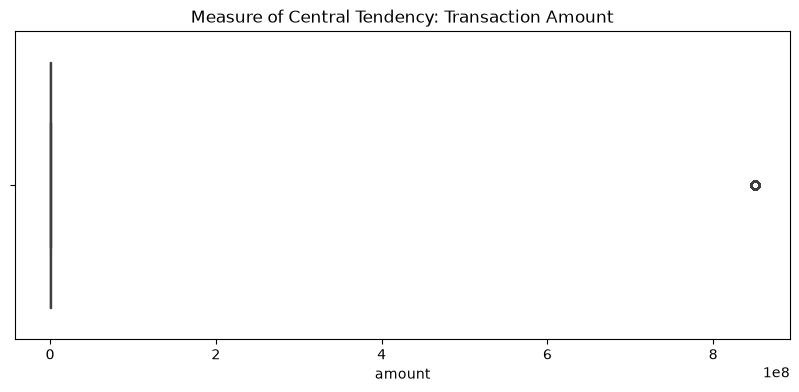

In [31]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='amount')
plt.title('Measure of Central Tendency: Transaction Amount')

In [32]:
#Check range of values, above upper bound
df[ (df['amount'] > upperbound) ]['amount'].describe()

count        2259.00
mean    850000000.00
std             0.00
min     850000000.00
25%     850000000.00
50%     850000000.00
75%     850000000.00
max     850000000.00
Name: amount, dtype: float64

In [33]:
df[df['amount'] >= upperbound]

,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount,remarks1
129,TRX-0000130,OVO-007650,2024-02-26,OVO Club,NaT,MCH-2354,Retail,2024-05-09,VA Billing,850000000,
267,TRX-0000268,OVO-016308,2023-02-13,OVO Club,NaT,P2P,P2P,2023-03-25,Transfer P2P,850000000,
513,TRX-0000514,OVO-036244,2023-01-05,OVO Premier,2023-01-15,P2P,P2P,2023-04-01,Transfer P2P,850000000,
657,TRX-0000658,OVO-024941,2023-04-11,OVO Club,NaT,MCH-3998,Retail,2023-05-01,Bill Payment,850000000,
856,TRX-0000857,OVO-021408,2024-03-03,OVO Club,NaT,P2P,P2P,2024-04-08,Transfer P2P,850000000,
...,...,...,...,...,...,...,...,...,...,...,...
299577,TRX-0299578,OVO-032119,2024-03-03,OVO Premier,2024-03-20,MCH-4458,F&B,2024-05-29,QRIS,850000000,
299637,TRX-0299638,OVO-025538,2024-03-08,OVO Club,NaT,MCH-1242,Retail,2024-06-11,QRIS,850000000,
299771,TRX-0299772,OVO-019999,2024-03-14,OVO Premier,2024-03-24,MCH-1782,F&B,2024-04-01,QRIS,850000000,
299883,TRX-0299884,OVO-010827,2023-03-02,OVO Premier,2023-03-28,TOP UP,TOP UP,2023-03-24,Top Up,850000000,


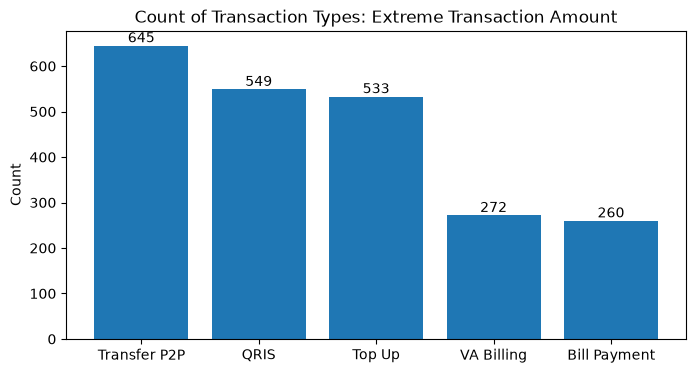

In [34]:
val_count = df[df['amount'] >= upperbound]['trx_type'].value_counts()

plt.figure(figsize=(8,4))
plt.bar(val_count.index, val_count.values)
plt.ylabel('Count')
plt.title('Count of Transaction Types: Extreme Transaction Amount')

#Annotation
for i in range(len(val_count)):
    plt.text(i,val_count.values[i],val_count.values[i],ha='center',va='bottom')


**Possible explanations:**
1. QRIS transaction limit since 2022 is capped at Rp 10 million. It is not possible to bypass the QRIS system. Db Administrator should be asked for this issue, whether the extracted data is incorrect or not.
2. Other type of payment, this transactions are unlikely to happen. Based on Indonesian Central Bank regulation, transactions processed through BI-Fast are capped at Rp 250 million each transaction. Transaction above Rp 250 million and below Rp 1 billion will be processed through SKNBI (which usually takes almost half business day). However, there's only a small chance that users breached security control. Therefore, this issue should be informed to Security Engineer. For now, these extreme transactions will be excluded and users will be remarked.

**Assumption:**\
Based on DB Administrator, there's mistaken in the data. Instead of Rp 850 million, it should be Rp 8.5 million 

In [35]:
# Change value based on Db Administrator
df['amount'] = df['amount'].replace(to_replace=850_000_000,value=8_500_000)

In [36]:
print ('Shape: ', df.shape, '\n')
df.describe()

Shape:  (300000, 11) 



,join_date,kyc_date,trx_date,amount
count,300000,180131,300000,300000.00
mean,2023-09-07 21:24:11.807999,2023-09-21 18:41:13.439885,2023-10-26 20:58:12.864000,562512.48
min,2023-01-01 00:00:00,2023-01-02 00:00:00,2022-12-20 00:00:00,10000.00
25%,2023-05-06 00:00:00,2023-05-19 00:00:00,2023-06-24 00:00:00,255033.75
50%,2023-09-08 00:00:00,2023-09-22 00:00:00,2023-10-28 00:00:00,505276.00
75%,2024-01-11 00:00:00,2024-01-25 00:00:00,2024-02-29 00:00:00,757599.00
max,2024-05-14 00:00:00,2024-06-11 00:00:00,2024-08-21 00:00:00,8500000.00
std,NaN,NaN,NaN,748325.22


Text(0.5, 1.0, 'Measure of Central Tendency: Transaction Amount after handled')

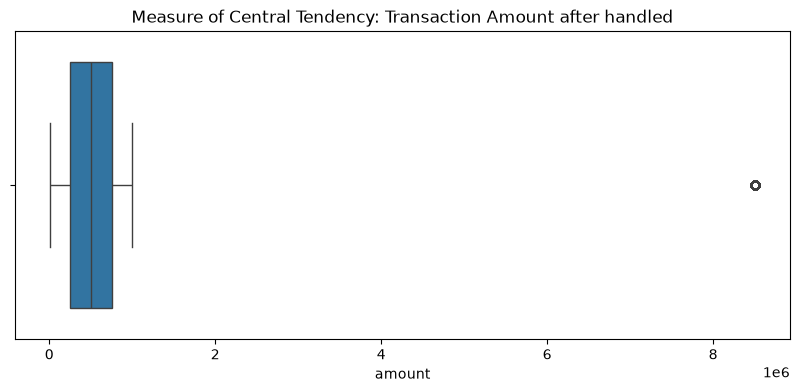

In [37]:
plt.figure(figsize=(10,4))
ax = sns.boxplot(data=df, x='amount')
ax.set_title('Measure of Central Tendency: Transaction Amount after handled')

#### Government Regulations

##### Limit Transaksi QRIS

Implementasi awal: 16 Agustus 2019 (PERATURAN ANGGOTA DEWAN GUBERNUR NOMOR 21/18/PADG/2019)\
Pasal 8 Ayat (1)\
Nominal Transaksi QRIS dibatasi paling banyak Rp2.000.000,00 (dua juta rupiah) per transaksi.

Perubahan: 25 Februari 2022 (PERATURAN ANGGOTA DEWAN GUBERNUR NOMOR 24/1/PADG/2022)\
Pasal 8 Ayat (1)\
Nominal Transaksi QRIS dibatasi paling banyak Rp10.000.000,00 (sepuluh juta rupiah) per transaksi.

##### Peraturan Bank Indonesia Nomor 20/6/PBI/2018 tentang Uang Elektronik

Pasal 3\
(2) Uang Elektronik sebagaimana dimaksud pada ayat (1) dapat dibedakan berdasarkan:\
&emsp;b. pencatatan data identitas Pengguna berupa:\
&emsp;&emsp;1. unregistered, yaitu Uang Elektronik yang data identitas Penggunanya tidak terdaftar dan tidak tercatat pada Penerbit; dan\
&emsp;&emsp;2. registered, yaitu Uang Elektronik yang data identitas Penggunanya terdaftar dan tercatat pada Penerbit. 

Pasal 45 \
(1) Batas Nilai Uang Elektronik yang dapat disimpan pada Uang Elektronik ditetapkan sebagai berikut:\
&emsp;a. untuk Uang Elektronik unregistered paling banyak Rp2.000.000,00 (dua juta rupiah); dan\
&emsp;b. untuk Uang Elektronik registered paling banyak Rp10.000.000,00 (sepuluh juta rupiah).\
(2) Batas nilai transaksi Uang Elektronik dalam 1 (satu) bulan paling banyak Rp20.000.000,00 (dua puluh juta rupiah).\
(3) Batas nilai transaksi Uang Elektronik sebagaimana dimaksud pada ayat (2) diperhitungkan dari transaksi yang bersifat incoming.\
(4) Batasan sebagaimana dimaksud pada ayat (1) dan ayat (2) tidak berlaku bagi akun pencatatan Nilai Uang Elektronik dari Penyedia Barang dan/atau Jasa.


##### UPDATE: Peraturan Anggota Dewan Gubernur Nomor 24/7/PADG/2022 (berlaku 1 Juli 2022)

Pasal 22\
(1) Batas nilai uang elektronik yang dapat disimpan pada uang elektronik ditetapkan:\
&emsp;a. untuk uang elektronik unregistered paling banyak Rp2.000.000,00 (dua juta rupiah); dan\
&emsp;b. untuk uang elektronik registered paling banyak Rp20.000.000,00 (dua puluh juta rupiah).

(2)Batas nilai transaksi uang elektronik dalam 1 (satu) bulan ditetapkan:\
&emsp;a. untuk uang elektronik unregistered paling banyak Rp20.000.000,00 (dua puluh juta rupiah); dan\
&emsp;b. untuk uang elektronik registered paling banyak Rp40.000.000,00 (empat puluh juta rupiah).

(3) Batas nilai transaksi uang elektronik sebagaimana dimaksud pada ayat (2) diperhitungkan dari transaksi yang bersifat incoming.

(4) Batas nilai uang elektronik sebagaimana dimaksud pada ayat (1) yang dapat disimpan dan batas nilai transaksi uang elektronik sebagaimana dimaksud pada ayat (2), tidak berlaku bagi akun pencatatan nilai uang elektronik dari Penyedia Barang dan/atau Jasa.

In [38]:
wallet_bal_unreg = 2_000_000
wallet_bal_reg = 40_000_000
limit_trx_unreg = 20_000_000
limit_trx_reg = 40_000_000

#### Users Compliance Check

##### 1. Users KYC Status vs Transaction Type

OVO Club = Bill Payment, QRIS, VA Bill, Top Up\
OVO Premier = Bill Payment, QRIS, VA Bill, Top Up, P2P

In [39]:
df_KYC_trx = df.groupby(df['kyc_status'],as_index=False)[['trx_type']].value_counts()

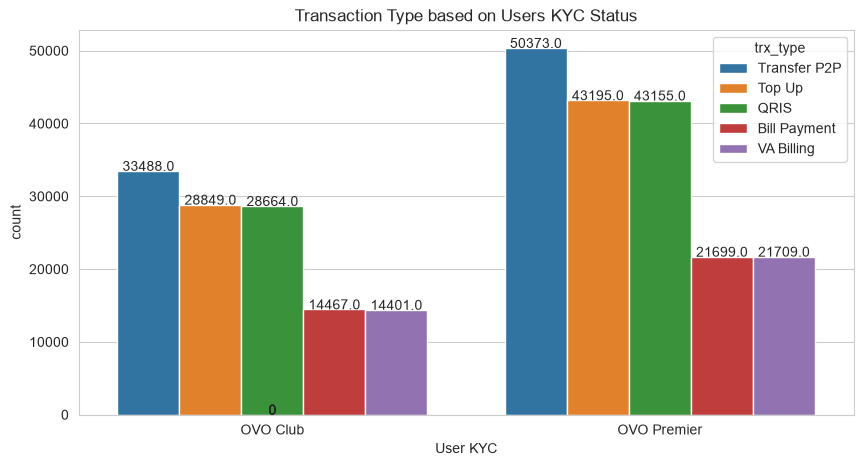

In [40]:
plt.figure(figsize=(10,5))
sns.set_style('whitegrid')
ax = sns.barplot(data=df_KYC_trx, x='kyc_status', y='count', hue='trx_type')
plt.title('Transaction Type based on Users KYC Status')
plt.ylabel('count')
plt.xlabel('User KYC')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, height, ha="center")

In [41]:
#OVO Club: do not have authorization for Transfer P2P; users will be remarked
df.loc[(df['kyc_status']=='OVO Club') & (df['trx_type']=='Transfer P2P'), ['remarks1']] = 'OVO Club P2P'

In [42]:
# OVO Premier: Transfer P2P has to be done after KYC Process
print (df[(df['kyc_status']=='OVO Premier') & (df['trx_type']=='Transfer P2P') & (df['trx_date']<df['kyc_date'])].shape,'\n')
df[(df['kyc_status']=='OVO Premier') & (df['trx_type']=='Transfer P2P') & (df['trx_date']<df['kyc_date'])].head()

(13225, 11) 



,trx_id,user_id,join_date,kyc_status,kyc_date,merchant_id,merchant_cat,trx_date,trx_type,amount,remarks1
55,TRX-0000056,OVO-036706,2024-02-11,OVO Premier,2024-03-06,P2P,P2P,2024-03-02,Transfer P2P,65993,
83,TRX-0000084,OVO-017614,2024-02-12,OVO Premier,2024-02-21,P2P,P2P,2024-02-09,Transfer P2P,567205,P2P before joined and KYC
99,TRX-0000100,OVO-032773,2023-09-21,OVO Premier,2023-09-22,P2P,P2P,2023-09-19,Transfer P2P,979338,P2P before joined and KYC
117,TRX-0000118,OVO-012593,2023-11-26,OVO Premier,2023-12-24,P2P,P2P,2023-12-13,Transfer P2P,997159,
122,TRX-0000123,OVO-003404,2023-04-14,OVO Premier,2023-05-12,P2P,P2P,2023-05-08,Transfer P2P,765497,


In [43]:
# OVO Premier: Transfer P2P has to be done after KYC Process
df.loc[ (df['kyc_status']=='OVO Premier') 
    & (df['trx_type']=='Transfer P2P') 
    & (df['trx_date']<df['kyc_date']) 
    & (df['remarks1']==''), ['remarks1'] ] = 'P2P before KYC'

In [44]:
#Count users who are marked
df_marked_user = df[df['remarks1']!=''].drop_duplicates(subset='user_id')
marked_user = df_marked_user['remarks1'].value_counts()

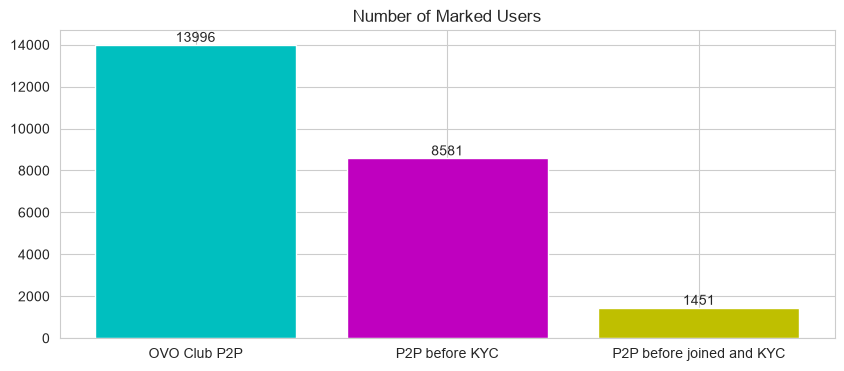

In [45]:
plt.figure(figsize=(10,4))
plt.bar(marked_user.index, marked_user.values, color=['c','m','y'])
plt.title('Number of Marked Users')

#Annotation
for i in range(len(marked_user)):
    plt.text(i,marked_user.values[i],marked_user.values[i],ha='center',va='bottom')


Text(0.5, 1.0, 'Percentage of Marked Users')

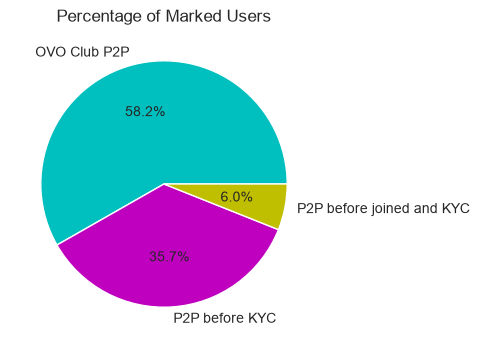

In [46]:
plt.figure(figsize=(10,4))

plt.pie(x=marked_user.values, labels = marked_user.index,autopct='%.1f%%', colors=['c','m','y'])
plt.title('Percentage of Marked Users')

##### 2. Wallet balance

In [47]:
#OVO Club: unregistered
unreg = df_users[ (df_users['kyc_status']=='OVO Club') & (df_users['wallet_balance']> wallet_bal_unreg ) ].describe()
unreg_adj = df_users[ (df_users['kyc_status']=='OVO Club') & (df_users['wallet_balance']> wallet_bal_unreg ) & (df_users['wallet_balance']<999_999_999) ].describe()

unreg = unreg.style.set_table_attributes("style='display:inline; margin-right:50px;'").set_caption('Unregistered/OVO Club')
unreg_adj = unreg_adj.style.set_table_attributes("style='display:inline; margin-right:50px;'").set_caption('OVO Club excl. 999,999,999')

#OVO Premiere: registered
reg = df_users[ (df_users['kyc_status']=='OVO Premier') & (df_users['wallet_balance']> wallet_bal_reg) ].describe()
reg = reg.style.set_table_attributes("style='display:inline; margin-right:50px;'").set_caption('Registered/OVO Premier')

#Extreme wallet balance (Both OVO Club & OVO Premier)
extreme_wallet = df_users[ (df_users['wallet_balance']>wallet_bal_reg) ].describe()
extreme_wallet = extreme_wallet.style.set_table_attributes("style='display:inline; margin-right:50px;'").set_caption('Extreme Wallet Balance')

#Anomaly wallet balance (below zero)
below_zero = df_users[ (df_users['wallet_balance']<0) ].describe()
below_zero = below_zero.style.set_table_attributes("style='display:inline; '").set_caption('Below Zero Wallet Balance')

display_html(unreg._repr_html_() + unreg_adj._repr_html_() + reg._repr_html_() + extreme_wallet._repr_html_() + below_zero._repr_html_(), raw=True)

,wallet_balance
count,9531.000000
mean,8822846.384954
std,72708561.259409
min,2000208.000000
25%,2761350.000000
50%,3467557.000000
75%,4262268.500000
max,999999999.000000
,wallet_balance
count,9480.000000


Based on compliance check on *wallet balance*, 
there are several unregistered (not KYC) users with balance exceed regulations threshold.\
As of registered users (done KYC), none are violating regulations threshold.\
However, there are users with balance recorded as below 0 and 999.999.999.\
Balance 999.999.999 is likely due to Database error.\
But, users with balance below 0 is likely due to Database error, or our system bugs that users able to transact even their balance is insufficient.\
Db Administrator should be informed.    

##### 3. Monthly transaction

In [48]:
df_monthly = df.groupby(['user_id', 'kyc_status', df['trx_date'].dt.strftime('%Y-%m') ], as_index=False)[['amount']].sum()
df_monthly = df_monthly.rename(columns={'trx_date':'month'})

In [49]:
user_20 = df_monthly[ df_monthly['amount']>=limit_trx_unreg ]
user_20

,user_id,kyc_status,month,amount
3099,OVO-000956,OVO Premier,2023-10,21174519


There is one registered user (with KYC) with monthly transactions above Rp 20 million, but still below regulated threshold.

#### Check Normality Distribution of Transaction Amount

In [50]:
def ptest (pval):
    if pval < 0.05:
        print(f"p-value: {pval}\t Reject null hypothesis. Accept Alternative Hypothesis")
    else:
        print(f"p-value: {pval}\t Fail to reject null hypothesis. Accept Null Hypothesis")

$H_0$ : Transaction amount distributed normally\
$H_1$ : Transaction amount not distributed normally

In [51]:
#Data records is over 5.000; Use D'Agostino & Pearson Test
ptest( stats.normaltest(df['amount'])[1] )

print ('Skewness: ', df['amount'].skew() )

p-value: 0.0	 Reject null hypothesis. Accept Alternative Hypothesis
Skewness:  8.950575715899436


<Axes: xlabel='amount', ylabel='Count'>

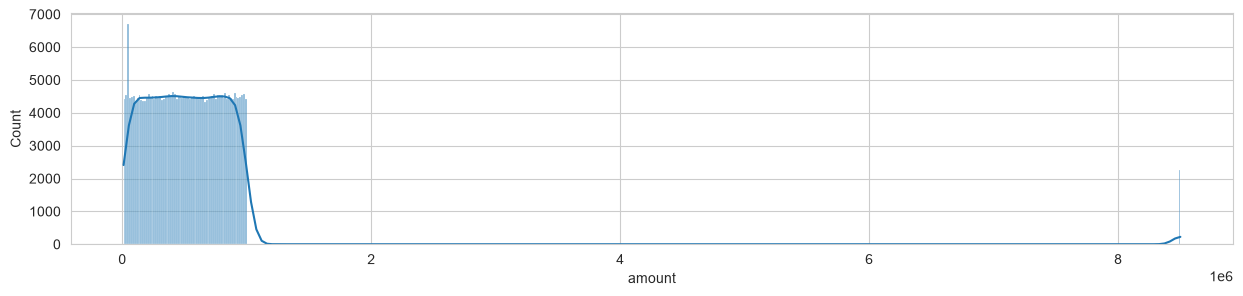

In [52]:
plt.figure(figsize=(15, 3))
sns.histplot(data=df['amount'], kde=True)

Based on D'Agostino & Pearson normality test, it is considered the "Amount Transaction" is not distributed normally.\
Based on the histogram, it is also shown that the data is uniformed (at range around Rp 1 million) with extreme value.\
This is also justified by the skewness = 8.9, which mean there are extreme values to the right side of the data.\
Conclusion: "Amount Transaction" is assumed not normally distributed (right skewed).

### Hypothesis

Hypothesis testing is conducted to understand whether there are specific pattern or transaction type, that has tendency to be fraud.\
In this dataset, Hypothesis will be conducted for several aspects.

##### 1. Hypothesis: Transactions across data type

Transaction amount is not distributed normally, Median will be used

$H_0$ : All transaction type have the same average (median) transaction amount\
$H_1$ : NOT all transaction type have the same average (median) transaction amount

In [53]:
df.groupby(df['trx_type'], as_index=False)[['amount']].describe()

trx_type   amount                                                   \
                   count      mean       std      min       25%       50%   
0  Bill Payment 36166.00 559713.43 733496.55 10015.00 254908.50 503026.00   
1          QRIS 71819.00 565528.54 752749.21 10015.00 257692.00 506738.00   
2        Top Up 72044.00 560089.70 743043.87 10027.00 252919.00 504699.50   
3  Transfer P2P 83861.00 563414.94 755111.56 10043.00 255019.00 506053.00   
4    VA Billing 36110.00 562055.12 748887.22 10000.00 254293.25 504075.00   

                        
        75%        max  
0 755818.50 8500000.00  
1 759671.00 8500000.00  
2 755896.50 8500000.00  
3 757616.00 8500000.00  
4 758795.50 8500000.00

Text(0.5, 0, 'Transaction Type')

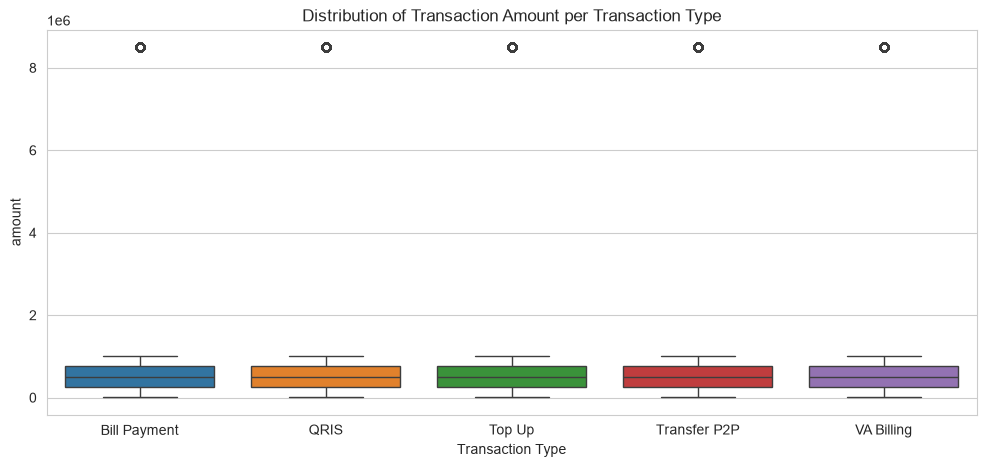

In [54]:
plt.figure(figsize=(12,5))
sns.set_style('whitegrid')

sns.boxplot(data=df, y='amount', x='trx_type', hue='trx_type')
plt.title('Distribution of Transaction Amount per Transaction Type')
plt.xlabel('Transaction Type')

In [55]:
#Group by transaction type
trxtype_amount = []

for trxtype in df['trx_type'].unique():
    trxtype_amount.append( df[df['trx_type']==trxtype]['amount'] )

ptest ( stats.kruskal(*trxtype_amount)[1] )

p-value: 0.19717572837108274	 Fail to reject null hypothesis. Accept Null Hypothesis


Based on Kruskal Wallis test, all transaction type have the same average (median) transaction amount.\
In terms of transaction amount for each transaction type, there are no significant difference which may lead to allegedly fraud transaction.

##### 2. Hypothesis: Transactions across merchant category

Transaction amount is not distributed normally, Median will be used

$H_0$ : All merchant category have the same average (median) transaction amount\
$H_1$ : NOT all merchant category have the same average (median) transaction amount

In [56]:
df.groupby(df['merchant_cat'], as_index=False)[['amount']].describe()

merchant_cat   amount                                                   \
                     count      mean       std      min       25%       50%   
0   Digital Goods 21687.00 567877.48 770352.33 10088.00 256015.50 503225.00   
1             F&B 57776.00 563216.08 746072.11 10000.00 255421.75 505578.50   
2          Others  7540.00 568721.75 760556.54 10132.00 262337.50 509659.00   
3             P2P 83861.00 563414.94 755111.56 10043.00 255019.00 506053.00   
4          Retail 43420.00 558210.68 724492.60 10015.00 255348.00 504735.00   
5          TOP UP 72044.00 560089.70 743043.87 10027.00 252919.00 504699.50   
6  Transportation 13672.00 568497.60 775517.06 10021.00 257305.25 504859.00   

                        
        75%        max  
0 760357.50 8500000.00  
1 759244.75 8500000.00  
2 763400.50 8500000.00  
3 757616.00 8500000.00  
4 755755.75 8500000.00  
5 755896.50 8500000.00  
6 758133.00 8500000.00

Text(0.5, 0, 'Merchant Category')

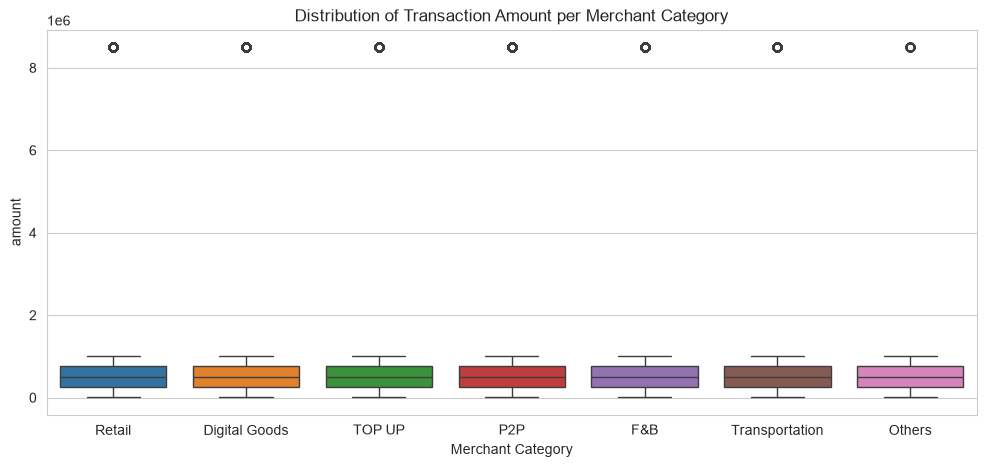

In [57]:
plt.figure(figsize=(12,5))
sns.set_style('whitegrid')

sns.boxplot(data=df, y='amount', x='merchant_cat', hue='merchant_cat')
plt.title('Distribution of Transaction Amount per Merchant Category')
plt.xlabel('Merchant Category')

In [58]:
#Group by merchant category
merchcat_amount = []

for merchcat in df['merchant_cat'].unique():
    merchcat_amount.append( df[df['merchant_cat']==merchcat]['amount'] )

ptest ( stats.kruskal(*trxtype_amount)[1] )

p-value: 0.19717572837108274	 Fail to reject null hypothesis. Accept Null Hypothesis


Based on Kruskal Wallis test, all merchant category have the same average (median) transaction amount.\
In terms of transaction amount for each merchant category, there are no significant difference which may lead to allegedly fraud transaction.

##### 3. Hypothesis: Transactions frequency
Data will be checked and compared based on transaction frequency.\
Transaction amount is not distributed normally, Median will be used

$H_0$ : All users have the same average (median) transaction amount\
$H_1$ : Users with low to average transaction frequency do not have the same average (median) transaction amount compared to users with high transaction frequency.

In [59]:
df_Trans_Freq = df.groupby(['user_id', df['trx_date'].dt.strftime('%Y-%m') ], as_index=False).agg({'trx_id':'count', 'amount':'sum'})
df_Trans_Freq.sort_values('trx_id', ascending=False).head(10)

,user_id,trx_date,trx_id,amount
128146,OVO-039157,2023-04,11,4609391
99493,OVO-030365,2023-07,11,5351080
28189,OVO-008607,2023-07,10,5031599
27816,OVO-008495,2023-08,10,3562723
125599,OVO-038384,2023-07,10,4952365
92195,OVO-028137,2023-12,10,4783669
45854,OVO-014001,2023-11,10,4803345
91510,OVO-027923,2023-03,10,12088579
122272,OVO-037367,2023-04,10,4484781
59307,OVO-018093,2023-08,10,5719377


In [60]:
df_Freq_Total = df_Trans_Freq.groupby(['user_id'],as_index=False)[['trx_id']].sum()
df_Freq_Total.rename(columns={'trx_id':'total_trx'},inplace=True)
df_Freq_Total = df_Freq_Total.sort_values(by='total_trx',ascending=False)
df_Freq_Total = df_Freq_Total.reset_index(drop=True)

In [61]:
df_Freq_Total['total_trx'].describe()

count   39969.00
mean        7.51
std         2.73
min         1.00
25%         6.00
50%         7.00
75%         9.00
max        21.00
Name: total_trx, dtype: float64

In [62]:
upper_bound_trx = df_Freq_Total['total_trx'].quantile(0.75) + (1.5 * (df_Freq_Total['total_trx'].quantile(0.75) - df_Freq_Total['total_trx'].quantile(0.25)) )
upper_bound_trx

np.float64(13.5)

In [63]:
high_Trx_user = df_Freq_Total[df_Freq_Total['total_trx'] > upper_bound_trx]['user_id']
high_Trx_user = high_Trx_user.to_list()

In [64]:
# Retrieve users with high transactions frequency
df_High = df[ (df['user_id'].isin(high_Trx_user)) | df['user_id'].isin(user_20['user_id']) ].reset_index(drop=True)

In [65]:
# Retrieve users with standard frequency
df_std = df[ (~df['user_id'].isin(high_Trx_user)) & ~df['user_id'].isin(user_20['user_id']) ].reset_index(drop=True)

In [66]:
print ('User who have high frequency transaction :' , df_High['user_id'].nunique() , 'users' )
print ('User who have standard frequency transaction :' , df_std['user_id'].nunique() , 'users' )

User who have high frequency transaction : 837 users
User who have standard frequency transaction : 39132 users


Text(0.5, 1.0, 'Percentage of High and Standard Transaction Frequency Users (Throughout Dataset Timeline')

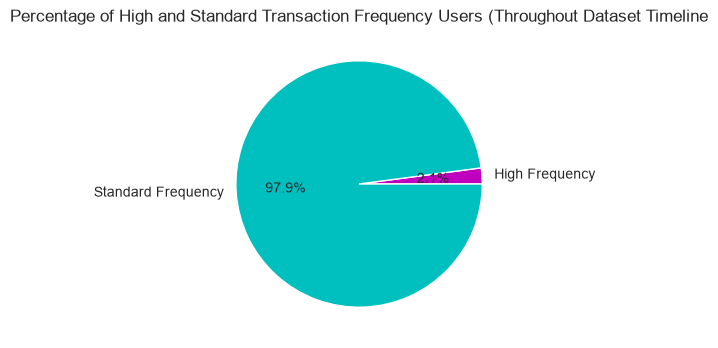

In [67]:
plt.figure(figsize=(10,4))

plt.pie(x=[df_High['user_id'].nunique(), df_std['user_id'].nunique()], 
        labels = ['High Frequency', 'Standard Frequency'],
        autopct='%.1f%%', colors=['m','c'])
plt.title('Percentage of High and Standard Transaction Frequency Users (Throughout Dataset Timeline')

In [68]:
high_freq = pd.DataFrame(df_High['amount'].describe())
std_freq = pd.DataFrame(df_std['amount'].describe())

high_freq = high_freq.style.set_table_attributes("style='display:inline; margin-right:40px;'").set_caption('High Frequency')
std_freq = std_freq.style.set_table_attributes("style='display:inline;'").set_caption('Standard Frequency')

display_html(high_freq._repr_html_() + std_freq._repr_html_(), raw=True)

,amount
count,12457.000000
mean,563354.125552
std,765437.221603
min,10062.000000
25%,252540.000000
50%,504427.000000
75%,749198.000000
max,8500000.000000
,amount
count,287543.000000


Text(0.5, 1.0, 'Distribution of Transaction Amount between High-Frequency vs Low-Frequency Users')

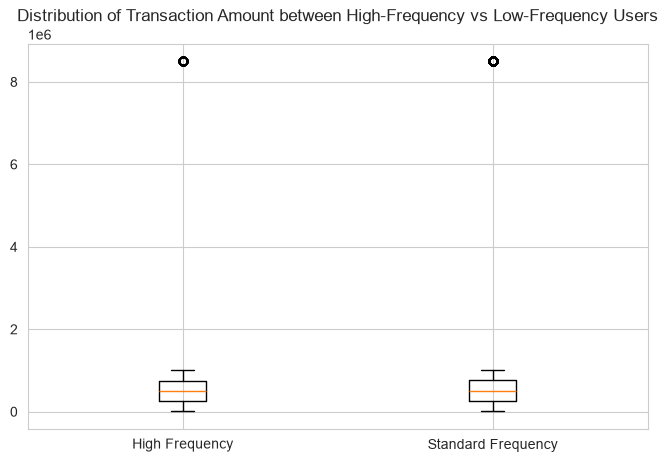

In [69]:
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')
plt.boxplot([df_High['amount'],df_std['amount']],tick_labels=['High Frequency','Standard Frequency'])
plt.title('Distribution of Transaction Amount between High-Frequency vs Low-Frequency Users')

In [70]:
#Compare 2 group of median

ptest( stats.mannwhitneyu(df_std['amount'], df_High['amount'], alternative='two-sided')[1] )

p-value: 0.3670079639020085	 Fail to reject null hypothesis. Accept Null Hypothesis


Based on Mann Whitney U test, users with low to average transaction frequency have the same average (median) transaction amount compared to users with high transaction frequency.

##### 4a. Hypothesis: Marked user
Data will be checked and compared based on marked user and non-marked user.\
Transaction amount is not distributed normally, Median will be used

$H_0$ : Two-group of users have the same average (median) transaction amount\
$H_1$ : Two-group of users DO NOT have the same average (median) transaction amount

In [71]:
#Users who are marked
df_marked_user = df[df['remarks1']!=''].drop_duplicates(subset='user_id')
marked_user = df_marked_user['user_id'].to_list()

df_marked_T = df[df['user_id'].isin(marked_user)==True]
df_marked_F = df[df['user_id'].isin(marked_user)==False]

Text(0.5, 1.0, 'Distribution of Transaction Amount between Marked (non-compliance) vs Non-Marked Users')

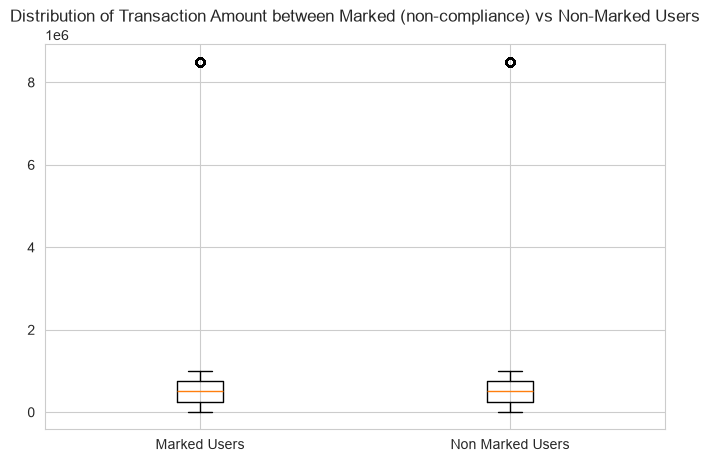

In [72]:
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')
plt.boxplot([df_marked_T['amount'],df_marked_F['amount']],tick_labels=['Marked Users','Non Marked Users'])
plt.title('Distribution of Transaction Amount between Marked (non-compliance) vs Non-Marked Users')

In [73]:

#Compare 2 group of median
ptest( stats.mannwhitneyu(df_marked_T['amount'], df_marked_F['amount'], alternative='two-sided')[1] )

p-value: 0.32519542091152387	 Fail to reject null hypothesis. Accept Null Hypothesis


##### 4b. Hypothesis: Marked user
Data will be checked and compared based on marked user and non-marked user.\
Transaction amount is not distributed normally, Median will be used

$H_0$ : Three-group of users have the same average (median) transaction amount\
$H_1$ : Three-group of users DO NOT have the same average (median) transaction amount

In [74]:
marked_user_OC = df[df['remarks1']=='OVO Club P2P']['user_id'].to_list()
df_marked_OC = df[df['user_id'].isin(marked_user_OC)==True]

marked_user_KYC = df[(df['remarks1']=='P2P before KYC') | (df['remarks1']=='P2P before joined and KYC')]['user_id'].to_list()
df_marked_KYC = df[df['user_id'].isin(marked_user_KYC)==False]

df_marked_F = df[(df['user_id'].isin(marked_user_OC)==False) & (df['user_id'].isin(marked_user_KYC)==False)]


Text(0.5, 1.0, 'Distribution of Transaction Amount amongst Marked OVO Club vs P2P before KYC vs Non-Marked Users')

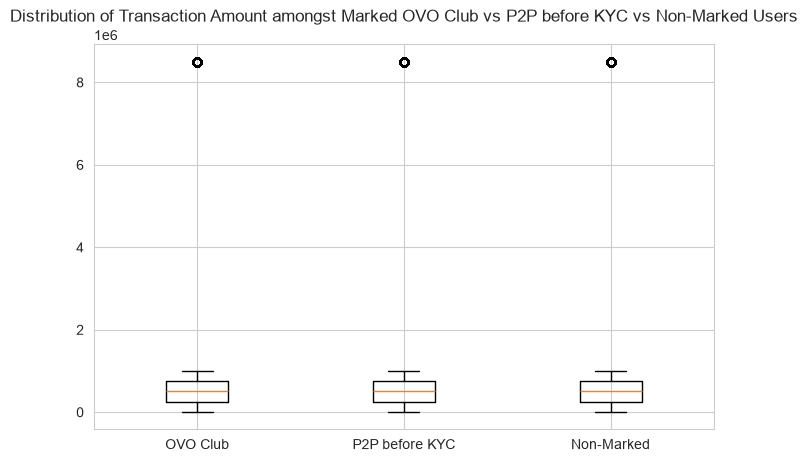

In [75]:
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')
plt.boxplot([df_marked_OC['amount'],df_marked_KYC['amount'],df_marked_F['amount']],tick_labels=['OVO Club','P2P before KYC', 'Non-Marked'])
plt.title('Distribution of Transaction Amount amongst Marked OVO Club vs P2P before KYC vs Non-Marked Users')

In [76]:

#Compare 3 group of median
ptest ( stats.kruskal(df_marked_OC['amount'], df_marked_KYC['amount'], df_marked_F['amount'])[1] )

p-value: 0.7931647635622885	 Fail to reject null hypothesis. Accept Null Hypothesis


Based on Mann Whitney U test, users with marked before (violate P2P) have the same average (median) transaction amount compared to users with non-marked.\
The result is also aligned with Kruskal test, users with each types of remarks have the same average (median) transaction amount compared to users with non-marked.

### Merchants Transaction Amount

Merchants sales amount (transactions) will be compared; the average sales across the time and the monthly sales\
Exception: transaction within OVO itself will be excluded (P2P transfer and Top Up)

Normally, it's better to compare average monthly transactions amount from the previous year, as merchant sales amount are varied on monthly basis.\
Since the dataset only contains 2-year of transaction, average monthly from previous quarter will be used.

In [77]:
# Exclude P2P and Top Up & Grouped by Quarter period (to calculate average transactions amount per month)
df_Q_merch = df[~df['merchant_cat'].isin(['TOP UP','P2P'])].groupby(['merchant_id', df['trx_date'].dt.to_period('Q') ], as_index=False)[['amount']].mean().sort_values('merchant_id',ascending=True)
df_Q_merch.rename(columns={'trx_date':'trx_Quarter', 'amount':'Qavg_month'},inplace=True)
df_Q_merch = df_Q_merch.reset_index(drop=True)
df_Q_merch['prev_Qavg_month'] = df_Q_merch.groupby(['merchant_id'])['Qavg_month'].shift(1)

In [78]:
#Grouped by transactions month, compared to previous Quarter period
df_month_merch = df[~df['merchant_cat'].isin(['TOP UP','P2P'])].groupby(['merchant_id', df['trx_date'].dt.strftime('%Y-%m') ], as_index=False)[['amount']].agg({'amount':'sum'}).sort_values('merchant_id',ascending=True)
df_month_merch['Quarter'] = pd.to_datetime(df_month_merch['trx_date']).dt.to_period('Q')
df_month_merch = df_month_merch.merge(right=df_Q_merch, how='left',left_on=['merchant_id', 'Quarter'], right_on=['merchant_id', 'trx_Quarter'])
df_month_merch = df_month_merch.drop(columns=['Quarter', 'trx_Quarter', 'Qavg_month'])
df_month_merch.rename(columns={'amount':'monthly_amount'}, inplace=True)

df_month_merch['avg_diff_amt'] = (df_month_merch['monthly_amount'] - df_month_merch['prev_Qavg_month'])
df_month_merch['avg_diff_percent'] = (df_month_merch['monthly_amount'] - df_month_merch['prev_Qavg_month']) *100 / df_month_merch['monthly_amount']
df_month_merch.head(10)


,merchant_id,trx_date,monthly_amount,prev_Qavg_month,avg_diff_amt,avg_diff_percent
0,MCH-0001,2023-02,990349,NaN,NaN,NaN
1,MCH-0001,2023-05,1563518,990349.00,573169.00,36.66
2,MCH-0001,2023-06,1454422,990349.00,464073.00,31.91
3,MCH-0001,2023-07,573817,502990.00,70827.00,12.34
4,MCH-0001,2023-08,1113051,502990.00,610061.00,54.81
5,MCH-0001,2023-09,826610,502990.00,323620.00,39.15
6,MCH-0001,2023-11,1415635,418913.00,996722.00,70.41
7,MCH-0001,2023-12,1188109,418913.00,769196.00,64.74
8,MCH-0001,2024-01,872172,520748.80,351423.20,40.29
9,MCH-0001,2024-02,9477967,520748.80,8957218.20,94.51


In [79]:

avg_amt = pd.DataFrame(df_month_merch['avg_diff_amt'].describe())
avg_pct = pd.DataFrame(df_month_merch['avg_diff_percent'].describe())

avg_amt = avg_amt.style.set_table_attributes("style='display:inline; margin-right:40px;'").set_caption('Avg Difference Amount')
avg_pct = avg_pct.style.set_table_attributes("style='display:inline;'").set_caption('Avg Difference Percentage')

display_html(avg_amt._repr_html_() + avg_pct._repr_html_(), raw=True)


,avg_diff_amt
count,63149.000000
mean,601019.142244
std,1319621.766001
min,-8479818.000000
25%,-27319.200000
50%,387009.500000
75%,950040.181818
max,20326592.400000
,avg_diff_percent
count,63149.000000


In [80]:
high_merch = df_month_merch[df_month_merch['avg_diff_percent'] > df_month_merch['avg_diff_percent'].quantile(0.50) ]['merchant_id']
high_merch.shape

(31574,)

In [81]:
df_merchQ3_user = df[(df['merchant_id'].isin(high_merch))].groupby(['merchant_id','user_id', df['trx_date'].dt.strftime('%Y-%m')])[['trx_id']].count().sort_values(by='trx_id', ascending=False)
df_merchQ3_user.rename(columns={'trx_id':'trx_frequency'},inplace=True)
df_merchQ3_user

trx_frequency
merchant_id user_id    trx_date               
MCH-0660    OVO-007941 2024-06               2
MCH-1157    OVO-016850 2023-03               2
MCH-0360    OVO-031649 2023-09               2
MCH-0511    OVO-009673 2023-06               2
MCH-1590    OVO-039637 2024-02               2
...                                        ...
MCH-0001    OVO-017183 2023-11               1
            OVO-017767 2024-03               1
            OVO-022855 2023-08               1
            OVO-024051 2024-03               1
            OVO-003531 2023-07               1

[144049 rows x 1 columns]

In [82]:
df_merch_alluser = df[~df['merchant_id'].isin(['TOP UP','P2P'])].groupby(['merchant_id','user_id', df['trx_date'].dt.strftime('%Y-%m')])[['trx_id']].count().sort_values(by='trx_id', ascending=False)
df_merch_alluser.rename(columns={'trx_id':'trx_frequency'},inplace=True)
df_merch_alluser

trx_frequency
merchant_id user_id    trx_date               
MCH-0660    OVO-007941 2024-06               2
MCH-1157    OVO-016850 2023-03               2
MCH-0360    OVO-031649 2023-09               2
MCH-0511    OVO-009673 2023-06               2
MCH-1590    OVO-039637 2024-02               2
...                                        ...
MCH-0001    OVO-017183 2023-11               1
            OVO-017767 2024-03               1
            OVO-022855 2023-08               1
            OVO-024051 2024-03               1
            OVO-003531 2023-07               1

[144081 rows x 1 columns]

Based on transaction amount per merchant, there is no significant increase on monthly transactions, compared to previous quarter periods.\
There is no significant transaction frequency from each user at any merchant in a month. Twice per month can be considered as low frequency

### Final Insights

Period of analysis: 20 Dec 2022 - 21 Aug 2024

#### Transactions system bugs:
1. Transaction amount recorded as below 0 (minus)
2. Several users can use P2P transfer feature of 'OVO Premier' even they haven't verified yet (KYC)
3. Several users without verification, can use P2P transfer

Follow up:\
Request system enhance to Security Engineer regarding these issues

#### User Compliance:
1. Several unregistered users' (without KYC) ending balance exceed the threshold amount as regulated from Bank Indonesia
2. Some users' ending balance are recorded as below 0 and 999.999.999
3. No user exceed monthly transaction limit (as regulated from Bank Indonesia)

Follow up:\
Request system enhance to Security Engineer regarding these issues and Db Administrator to ensure good data quality

#### Suspicious Transaction Check:
In terms of fraud transactions pattern, several aspects have been analyzed.\
Usually, certain user make repetitive transactions in a specific merchant. This analysis was conducted based on this knowledge.

1. Compared average monthly transactions with previous quarter average monthly transactions\
   *As data expanded, comparison with previous year average monthly transactions should be preferable*
2. Checked transaction frequency of users for each merchants\
   Each users didn't make any significant transaction frequency, with the highest frequency recorded as 2 (in a month).
3. P2P and Top Up transactions are excluded in this fraud checking.\
   P2P is transfer between users.\
   Top Up is financial transactions within the application itself

Conclusion:\
In this datasets, there are no specific pattern that is seen as suspicious. More data records will be needed for further analysis.

### Export Cleaned Data for Dashboard

In [83]:
# #Export Cleaned data for Dashboard purpose
# df_monthly.to_csv(path + 'user_trx_monthly_cleaned.csv')
# df.to_csv(path + 'ovo_transactions_cleaned.csv')